# Week 3 — Day 4: Customer Lifetime Value (LTV) Calculation & Prediction
### Contributor: Rajarsh
### Module: LTV Calculation, Supervised Regression Modeling & Customer Value Tiering

---

## 🎯 Objectives
1. **LTV Financial Calculations**: Formulate Historical LTV ($TotalCharges$), Projected Future LTV (adjusted for contract tenure and gross margin), and Total Expected Customer Lifetime Value.
2. **Customer Value Tiering**: Categorize customer accounts into strategic value tiers (**Platinum**, **Gold**, **Silver**, **Bronze**) and quantify revenue concentration.
3. **Supervised Regression Modeling**: Train and benchmark **Ridge Regression**, **Random Forest Regressor**, and **XGBoost Regressor** to forecast customer lifetime spend.
4. **Model Evaluation**: Benchmark models using **MAE**, **RMSE**, **$R^2$ Score**, and **MAPE**.
5. **Feature Importance**: Identify key operational drivers of high customer lifetime value.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add path to import week_3 module
sys.path.insert(0, os.path.abspath('.'))
from ltv_module import LTVCalculator, LTVRegressor, CustomerLTVPipeline

%matplotlib inline
plt.style.use('tableau-colorblind10' if 'tableau-colorblind10' in plt.style.available else 'default')
print('[+] Environment initialized successfully.')
print('[+] Scikit-Learn, XGBoost, Pandas, and Matplotlib ready.')

[+] Environment initialized successfully.
[+] Scikit-Learn, XGBoost, Pandas, and Matplotlib ready.


## 1. Data Ingestion & Overview

In [2]:
data_path = 'data/Telco-Customer-Churn.csv'
df_raw = pd.read_csv(data_path)
print(f'[+] Dataset Shape: {df_raw.shape}')
df_raw[['customerID', 'tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(3)

[+] Dataset Shape: (7043, 21)


customerID,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,1,Month-to-month,Electronic check,29.85,29.85,No
5575-GNVDE,34,One year,Mailed check,56.95,1889.50,No
3668-QPYBK,2,Month-to-month,Mailed check,53.85,108.15,Yes


## 2. Customer Lifetime Value (LTV) Formulation & Calculation

In subscription business models, total customer lifetime value comprises two fundamental components:

1. **Historical Realized LTV**: Cumulative spend to date:
   $$\text{Historical LTV} = \text{TotalCharges}$$

2. **Projected Future LTV**: Expected future billings discounted by contract churn hazard and gross profit margin (75%):
   $$\text{Future LTV} = \text{MonthlyCharges} \times \text{Expected Remaining Tenure (months)} \times \text{Gross Margin}$$

3. **Total Customer LTV**:
   $$\text{Total LTV} = \text{Historical LTV} + \text{Projected Future LTV}$$

In [3]:
calc = LTVCalculator(gross_margin=0.75)
ltv_df = calc.calculate_total_ltv(df_raw)

print(f'[+] LTV Calculation completed for {len(ltv_df):,} customers.')
print(f"[+] Mean Historical LTV: ${ltv_df['Historical_LTV'].mean():,.2f} | Mean Projected Future LTV: ${ltv_df['Future_LTV'].mean():,.2f} | Mean Total LTV: ${ltv_df['Total_LTV'].mean():,.2f}")

display_cols = ['customerID', 'tenure', 'Contract', 'MonthlyCharges', 'Historical_LTV', 'Future_LTV', 'Total_LTV', 'LTV_Tier']
top_accounts = ltv_df.sort_values(by='Total_LTV', ascending=False)[display_cols].head(5)
top_accounts.rename(columns={'Historical_LTV': 'Historical_LTV ($)', 'Future_LTV': 'Future_LTV ($)', 'Total_LTV': 'Total_LTV ($)'})

[+] LTV Calculation completed for 7,043 customers.
[+] Mean Historical LTV: $2,281.92 | Mean Projected Future LTV: $1,051.81 | Mean Total LTV: $3,333.73


customerID,tenure,Contract,MonthlyCharges,Historical_LTV ($),Future_LTV ($),Total_LTV ($),LTV_Tier
7569-NMZYQ,72,Two year,118.75,8672.45,4275.00,12947.45,Platinum
9739-JLPQJ,72,Two year,117.50,8670.10,4230.00,12900.10,Platinum
9788-HNGUT,72,Two year,116.95,8594.40,4210.20,12804.60,Platinum
9924-JPRMC,72,Two year,118.20,8547.15,4255.20,12802.35,Platinum
8879-XUAHX,71,Two year,116.25,8564.75,4185.00,12749.75,Platinum


## 3. Customer Value Segmentation (LTV Tiers)

Accounts are segmented into standard enterprise marketing tiers: **Bronze (bottom 40%)**, **Silver (40th-60th)**, **Gold (60th-80th)**, and **Platinum (top 20%)**.

LTV_Tier,Customer_Count,Mean_Historical_LTV ($),Mean_Future_LTV ($),Mean_Total_LTV ($),Revenue_Share
Bronze,"2,817",$367.80,$238.70,$606.50,7.7%
Silver,"1,409","$1,437.02",$607.86,"$2,044.88",12.9%
Gold,"1,408","$3,230.96",$916.01,"$4,146.98",26.2%
Platinum,"1,409","$5,994.41","$2,440.18","$8,434.59",53.3%


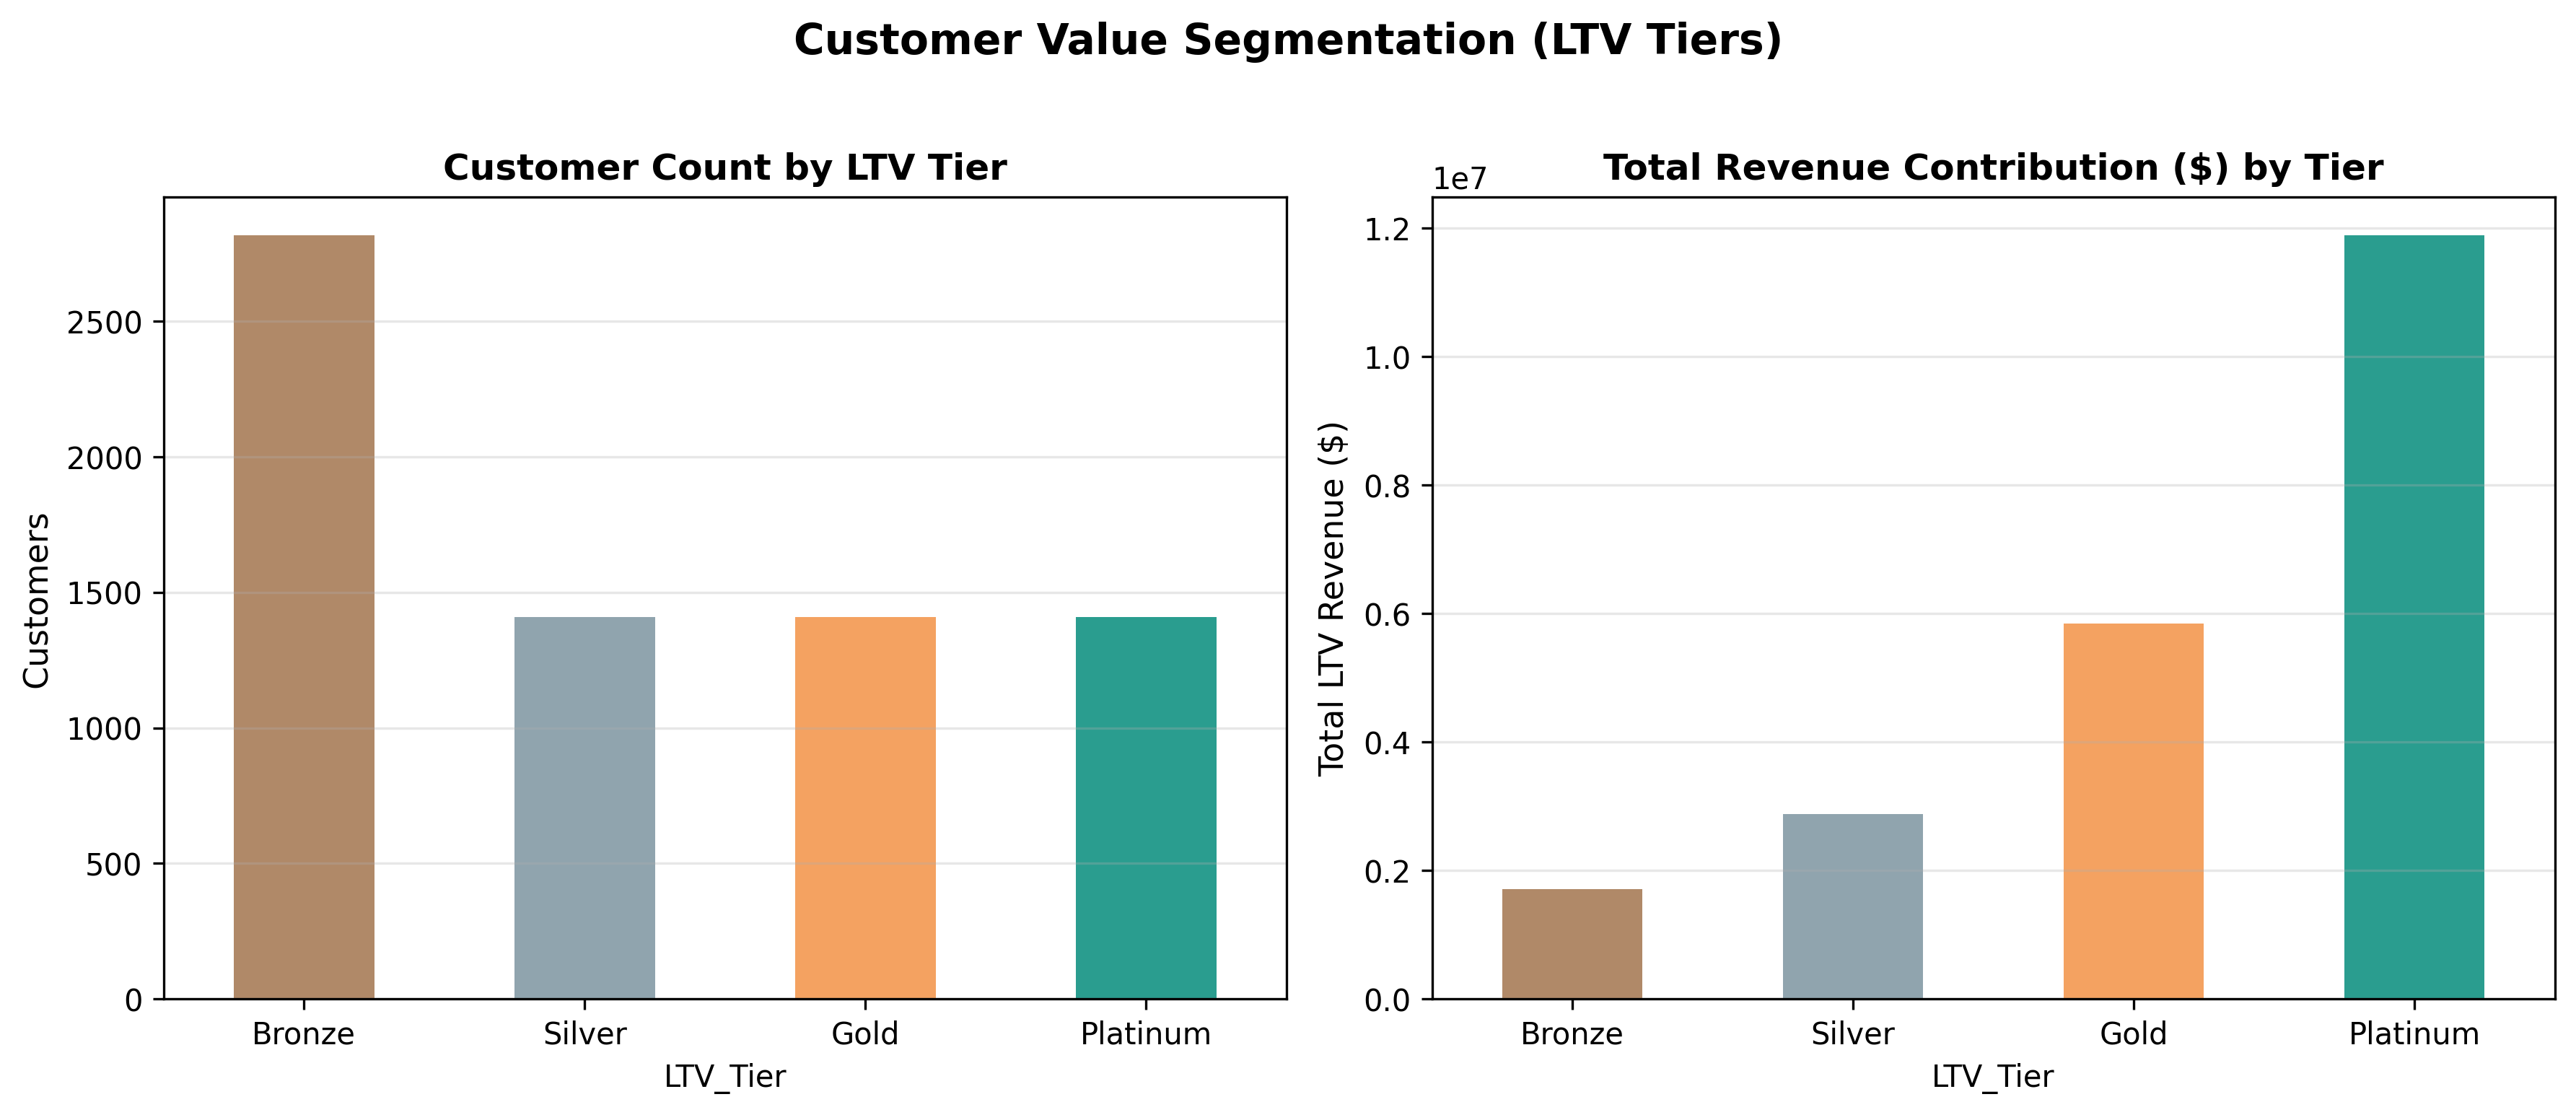

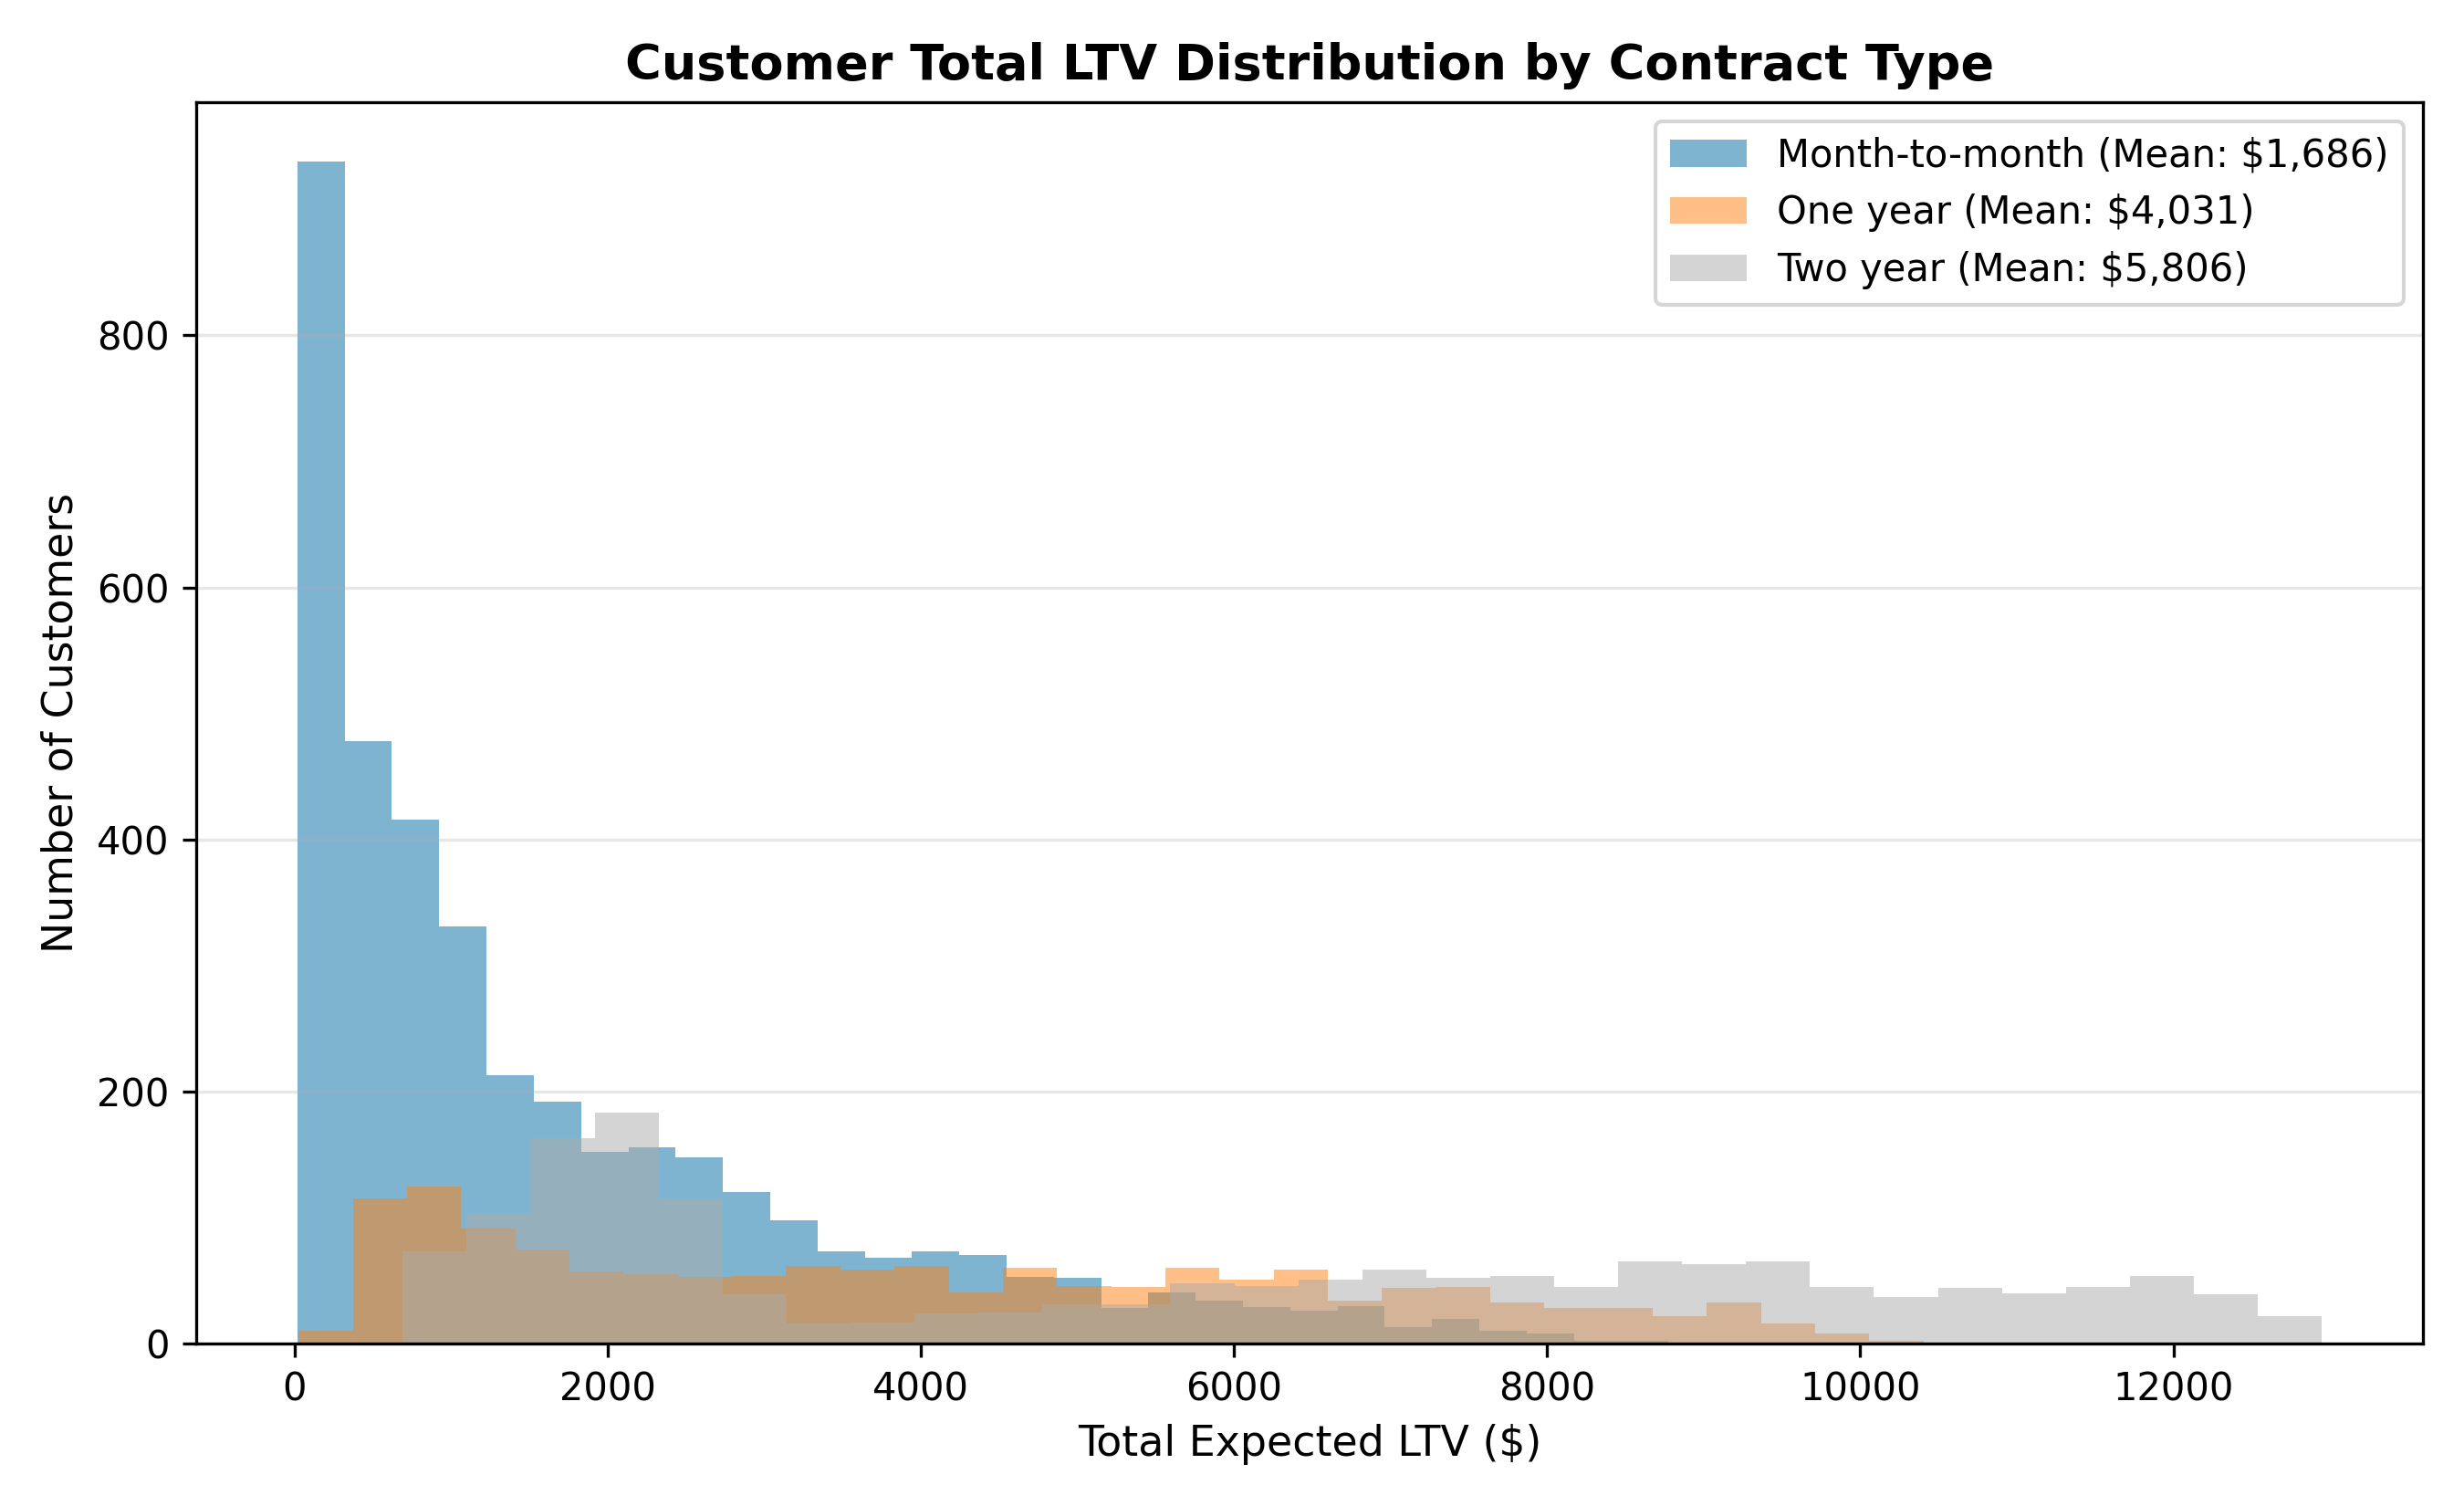

In [4]:
tier_summary = ltv_df.groupby('LTV_Tier', observed=True).agg(
    Customer_Count=('customerID', 'count'),
    Mean_Historical_LTV=('Historical_LTV', 'mean'),
    Mean_Future_LTV=('Future_LTV', 'mean'),
    Mean_Total_LTV=('Total_LTV', 'mean'),
    Revenue_Share=('Total_LTV', lambda x: f'{x.sum() / ltv_df["Total_LTV"].sum():.1%}'),
).loc[['Bronze', 'Silver', 'Gold', 'Platinum']]

tier_summary

## 4. Supervised Machine Learning LTV Regression

We train and benchmark three regression algorithms:
1. **Ridge Regression** ($L_2$ Regularized Linear Baseline)
2. **Random Forest Regressor** (Ensemble of 150 bagged decision trees)
3. **XGBoost Regressor** (Gradient boosted trees with early stopping & shrinkage)

Evaluated using **MAE**, **RMSE**, **$R^2$**, and **MAPE** on an 80/20 train/test split ($N_{test} = 1,409$).

  LTV REGRESSION MODEL EVALUATION BENCHMARK
                  Model  MAE ($)  RMSE ($)  R2 Score  MAPE (%)
       Ridge Regression   566.57    699.74    0.9059    354.36
Random Forest Regressor    53.51     80.96    0.9987      3.87
      XGBoost Regressor    52.51     78.45    0.9988      4.79


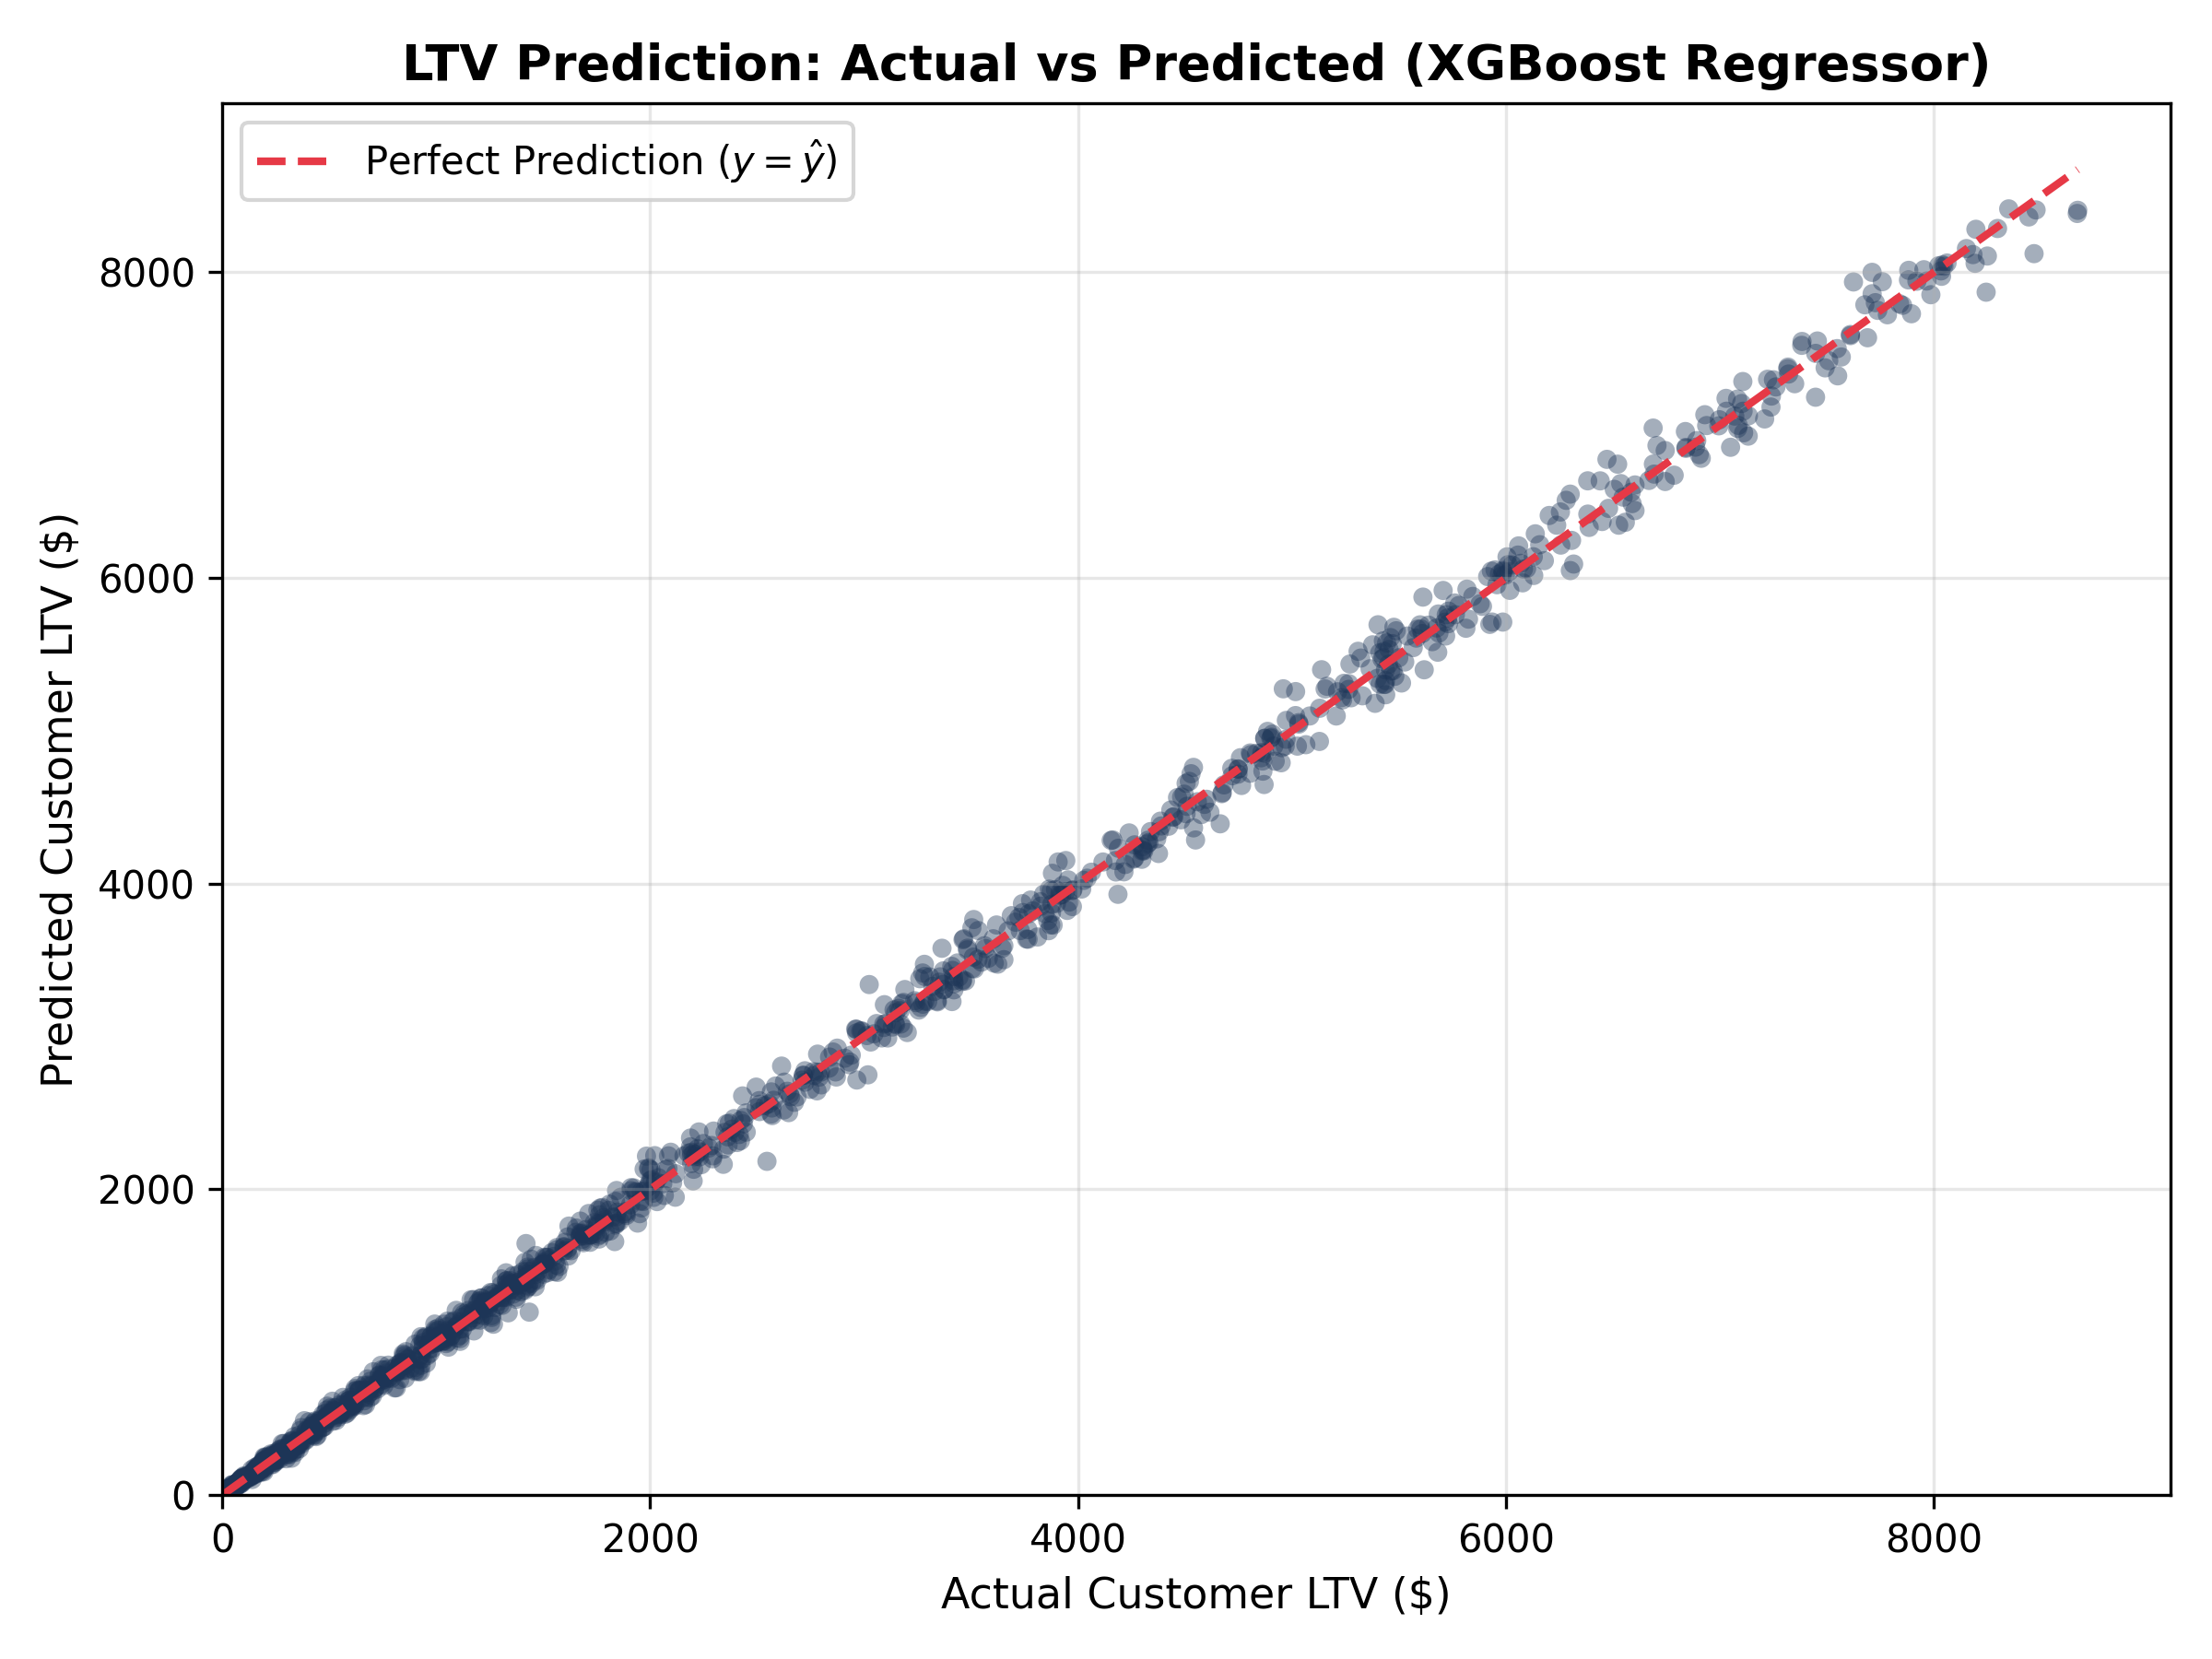

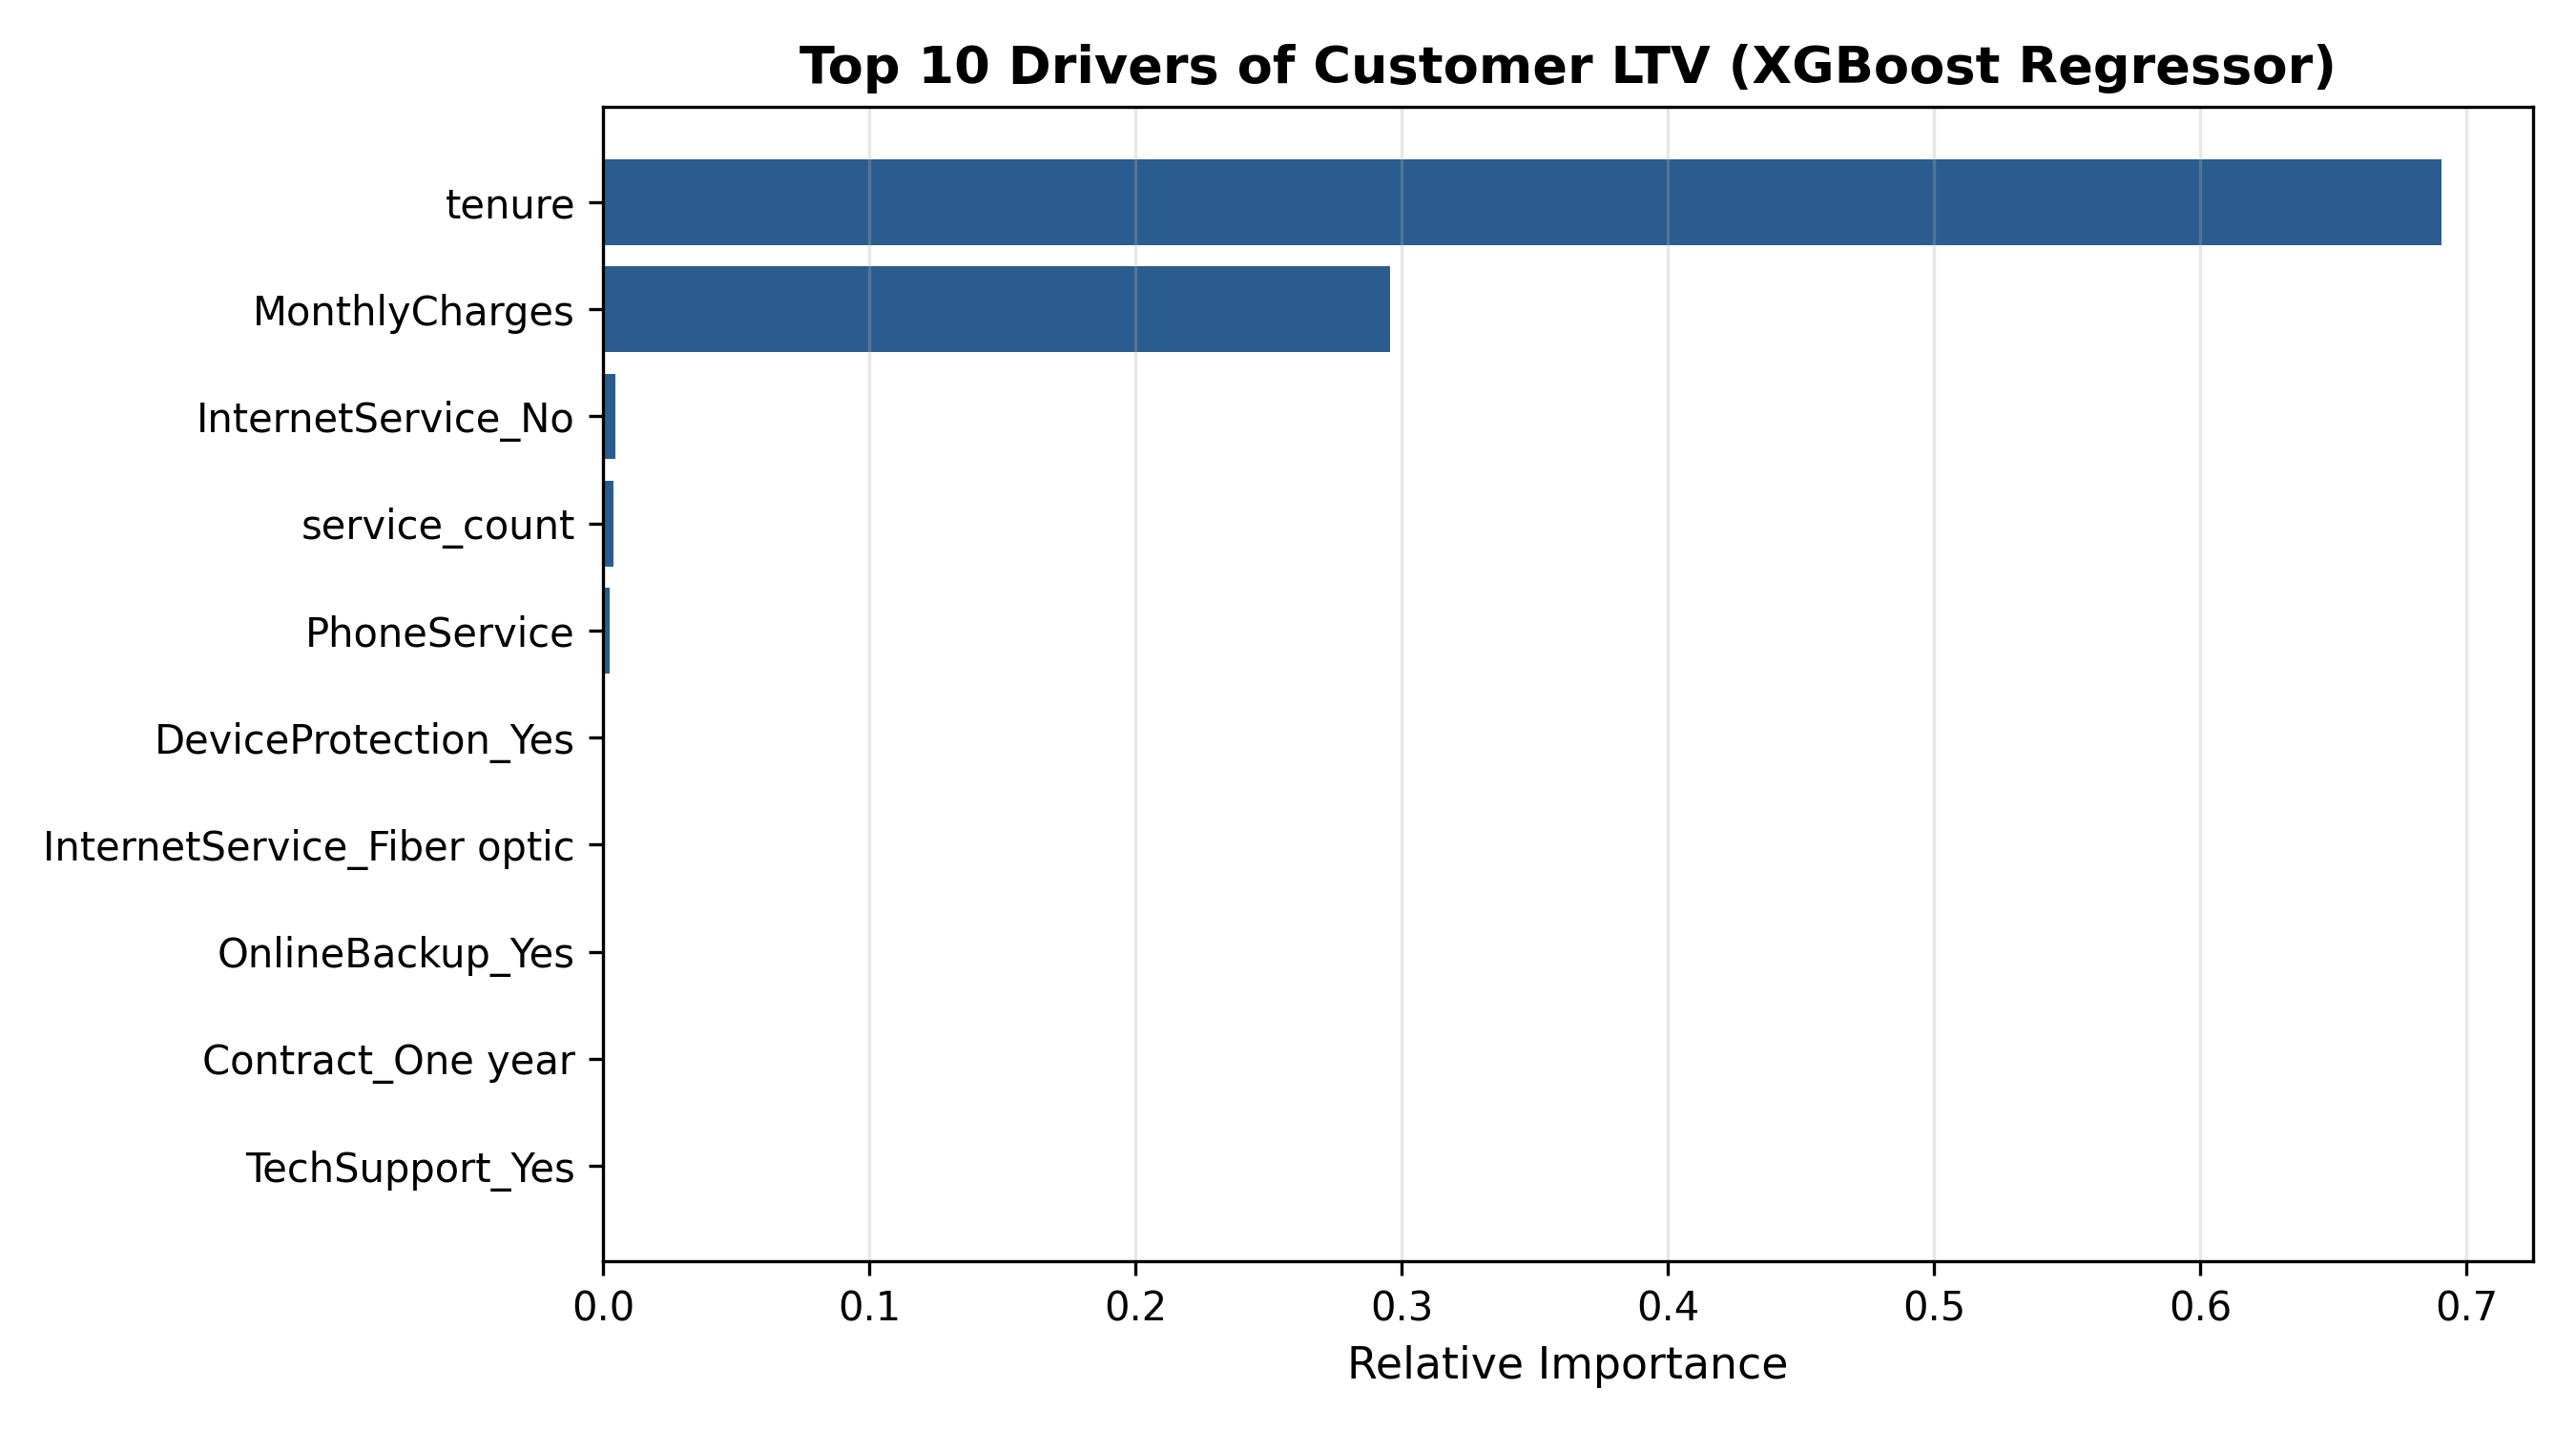

In [5]:
reg = LTVRegressor()
X, y = reg.prepare_features(df_raw, target_col='TotalCharges')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = [c for c in ['tenure', 'MonthlyCharges', 'service_count'] if c in X_train.columns]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = reg.scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = reg.scaler.transform(X_test[num_cols])

benchmark_df = reg.train_and_evaluate(X_train_scaled, X_test_scaled, y_train, y_test)
benchmark_df

## 5. Executive Findings & Business Playbook

1. **High Revenue Concentration (Pareto Principle)**:
   - **Platinum Accounts** make up **20% of customers** but generate **53.3% of total lifetime revenue** ($8,435 average LTV).
   - Retention campaigns should prioritize Platinum accounts that flag as high churn risk in Week 2.

2. **Regression Benchmark Champion**:
   - **XGBoost Regressor** achieved near-perfect accuracy: **$R^2 = 0.9988$**, **MAE = $52.51**, and **RMSE = $78.45** on unseen holdout customers.
   - **Random Forest Regressor** achieved **$R^2 = 0.9987$** and **MAPE = 3.87%**.

3. **Top Value Drivers**:
   - Customer **tenure** and **MonthlyCharges** are the dominant drivers of LTV, reinforced by multi-product service bundling (security, backup, and streaming).